# AOO Preprocess (rwalksa / rwalk1a / rwalkra)
Compute AOO for three variables and plot median density curves.

In [ ]:
# (1) Paths
import os
PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "global40.dta")
BASE_DIR  = os.path.join(PROJECT_ROOT, "results", "f1_aoo")

COUNTRY_DIR = os.path.join(BASE_DIR, "country")
GLOBAL_DIR  = os.path.join(BASE_DIR, "global")
MERGED_DIR  = os.path.join(BASE_DIR, "merged")

for d in [BASE_DIR, COUNTRY_DIR, GLOBAL_DIR, MERGED_DIR]:
    os.makedirs(d, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("BASE_DIR :", BASE_DIR)

In [43]:
# (2) Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

print("OK: imports done.")

OK: imports done.


In [44]:
# (3) Settings
START_AGE = 40
AGE_MAX = 100
X_MIN = 40
X_MAX = 100
FONT_SIZE = 7
W_INCH_DOUBLE = 7.0
H_INCH_SINGLE = 2.8
DPI_OUT = 600


COLORS = {
    "rwalksa": "#4E9FCF",  
    "rwalk1a": "#E16164",  
    "rwalkra": "#8793A9",  
}
COLORS1 = {
    "rwalksa": "#F5C18B",  
    "rwalk1a": "#F59A9C",  
    "rwalkra": "#9FC7DB",  
}

LABELS = {
    "rwalksa": "Walking several blocks",
    "rwalk1a": "Walking one block",
    "rwalkra": "Walking across a room",
}

print("START_AGE:", START_AGE, "AGE_MAX:", AGE_MAX)

START_AGE: 40 AGE_MAX: 100


In [45]:
# (4) Load & clean data
raw = pd.read_stata(DATA_PATH)
raw = (
    raw.assign(
        id=raw["id"].astype(str),
        age=pd.to_numeric(raw["ragey_b"], errors="coerce"),
        country=raw["isocountry_c"].astype(str),
        rwalksa=pd.to_numeric(raw.get("rwalksa"), errors="coerce"),
        rwalk1a=pd.to_numeric(raw.get("rwalk1a"), errors="coerce"),
        rwalkra=pd.to_numeric(raw.get("rwalkra"), errors="coerce"),
    )
    .loc[:, ["id", "age", "country", "rwalksa", "rwalk1a", "rwalkra"]]
    .dropna(subset=["id", "country", "age"])
    .loc[lambda d: d["country"].str.strip() != "", :]
)

for v in ["rwalksa", "rwalk1a", "rwalkra"]:
    raw[v] = raw[v].where(raw[v].isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())

raw shape: (1206788, 6)
countries: 40


In [46]:
# (5) Compute AOO per variable (prefer cached)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
aoo_parquet = os.path.join(DATA_DIR, "aoo_person_level.parquet")
aoo_csv = os.path.join(DATA_DIR, "aoo_person_level.csv")

aoo_all_df = None
if os.path.exists(aoo_parquet):
    try:
        aoo_all_df = pd.read_parquet(aoo_parquet)
        print("Loaded AOO cache:", aoo_parquet)
    except Exception as e:
        print("Warning: failed to read AOO parquet; will try CSV. Error:", str(e))
if aoo_all_df is None and os.path.exists(aoo_csv):
    aoo_all_df = pd.read_csv(aoo_csv)
    print("Loaded AOO cache:", aoo_csv)

computed_from_raw = False
if aoo_all_df is not None:
    aoo_data = {
        v: aoo_all_df.loc[aoo_all_df["variable"] == v, ["country", "id", "aoo"]].copy()
        for v in ["rwalksa", "rwalk1a", "rwalkra"]
    }
else:
    computed_from_raw = True
    def compute_aoo(df: pd.DataFrame, var: str) -> pd.DataFrame:
        rows = []
        for (country, pid), g in df.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
            valid = g.loc[g[var].notna(), ["age", var]]
            if valid.empty:
                continue
            event_ages = valid.loc[valid[var] == 1, "age"]
            event_ages = event_ages[(event_ages >= START_AGE) & (event_ages <= AGE_MAX)]
            if event_ages.empty:
                continue
            aoo = float(event_ages.min())
            rows.append({"country": str(country), "id": str(pid), "aoo": aoo})
        return pd.DataFrame(rows)

    aoo_data = {v: compute_aoo(raw, v) for v in ["rwalksa", "rwalk1a", "rwalkra"]}

for v, df in aoo_data.items():
    print(v, "AOO rows:", df.shape[0])

Loaded AOO cache: /Users/karwailin/Desktop/OAwalk/data/aoo_person_level.csv
rwalksa AOO rows: 53312
rwalk1a AOO rows: 88657
rwalkra AOO rows: 33410


In [47]:
# (5b) Save person-level AOO for reuse (only if computed)
os.makedirs(DATA_DIR, exist_ok=True)

if computed_from_raw:
    aoo_all = []
    for v, df in aoo_data.items():
        if df is None or df.empty:
            continue
        tmp = df.copy()
        tmp["variable"] = v
        aoo_all.append(tmp)

    if aoo_all:
        aoo_all_df = pd.concat(aoo_all, ignore_index=True)
        try:
            aoo_all_df.to_parquet(aoo_parquet, index=False)
            print("Saved:", aoo_parquet)
        except Exception as e:
            print("Parquet save failed, fallback to CSV. Error:", str(e))
            aoo_all_df.to_csv(aoo_csv, index=False)
            print("Saved:", aoo_csv)
    else:
        print("No AOO rows to save.")
else:
    print("AOO cache already loaded; skip recompute/save.")


AOO cache already loaded; skip recompute/save.


In [48]:
# (6) Plot helpers
def theme_std(ax: plt.Axes, font_size: int = 9):
    ax.set_facecolor("white")
    ax.tick_params(axis="both", labelsize=font_size, width=0.5, length=2.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")
    ax.xaxis.label.set_fontsize(font_size)
    ax.yaxis.label.set_fontsize(font_size)
    if ax.get_title():
        ax.title.set_fontsize(font_size)

def save_plot(fig: plt.Figure, path: str):
    base, _ = os.path.splitext(path)
    pdf_path = f"{base}.pdf"
    fig.savefig(pdf_path, dpi=DPI_OUT, bbox_inches="tight", facecolor='white', edgecolor='none')
    plt.close(fig)

def kde_curve(vals: np.ndarray):
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return None, None
    if np.nanmin(vals) == np.nanmax(vals):
        return None, None
    kde = gaussian_kde(vals)
    x_grid = np.linspace(np.nanmin(vals), np.nanmax(vals), 200)
    y_grid = kde(x_grid)
    return x_grid, y_grid

def mode_x(vals: np.ndarray):
    xg, yg = kde_curve(vals)
    if xg is not None:
        return float(xg[np.argmax(yg)])
    if len(vals) == 1:
        return float(vals[0])
    return None

def add_mode_marker(ax: plt.Axes, x: float, color: str):
    if x is None or not np.isfinite(x):
        return
    ax.plot(
        [x],
        [0.03],
        transform=ax.get_xaxis_transform(),
        marker="o",
        markersize=4,
        color=color,
        clip_on=False,
    )

def add_median_marker(ax: plt.Axes, x: float, color: str):
    if x is None or not np.isfinite(x):
        return
    ax.plot(
        [x],
        [0.08],
        transform=ax.get_xaxis_transform(),
        marker="^",
        markersize=4,
        color=color,
        clip_on=False,
    )

def add_marker_legend(
    ax: plt.Axes,
    font_size: int,
    main_loc: str = "upper left",
    marker_loc: str = "upper left",
    marker_bbox: tuple = (0.0, 0.80),
):
    marker_handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=4, label="Mode"),
        Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=4, label="Median"),
    ]
    handles, labels = ax.get_legend_handles_labels()
    main_leg = ax.legend(
        handles,
        labels,
        loc=main_loc,
        frameon=True,
        fontsize=font_size,
    )
    ax.add_artist(main_leg)
    ax.legend(
        marker_handles,
        ["Mode", "Median"],
        loc=marker_loc,
        bbox_to_anchor=marker_bbox,
        frameon=True,
        fontsize=font_size,
    )

def plot_density(ax, vals, color, label, lw=1.2, alpha_fill=0.0):
    xg, yg = kde_curve(vals)
    if xg is not None:
        ax.plot(xg, yg, color=color, linewidth=lw, label=label)
        if alpha_fill > 0:
            ax.fill_between(xg, 0, yg, color=color, alpha=alpha_fill)
        return
    if len(vals) == 1:
        ax.axvline(vals[0], color=color, linewidth=lw, label=label)

In [49]:
# (7) Per-country combined (three variables)
for ctry in sorted(raw["country"].unique()):
    fig, ax = plt.subplots(figsize=(W_INCH_DOUBLE, H_INCH_SINGLE), dpi=100)
    has_any = False
    for v in ["rwalksa", "rwalk1a", "rwalkra"]:
        df = aoo_data[v]
        vals = df.loc[df["country"] == ctry, "aoo"].values
        if len(vals) == 0:
            continue
        label = f"{LABELS[v]} (n={len(vals):,})"
        plot_density(ax, vals, COLORS[v], label, lw=1.2, alpha_fill=0.0)
        mx = mode_x(vals)
        add_mode_marker(ax, mx, COLORS[v])
        med = float(np.median(vals))
        add_median_marker(ax, med, COLORS[v])
        has_any = True
    if not has_any:
        plt.close(fig)
        continue
    ax.set_xlabel("Age at first onset of mobility difficulty (years)", fontsize=FONT_SIZE)
    ax.set_ylabel("Density", fontsize=FONT_SIZE)
    ax.set_title(f"AOO density (3 vars): {ctry}", fontsize=FONT_SIZE)
    ax.set_xlim(X_MIN, X_MAX)
    add_marker_legend(ax, FONT_SIZE-1)
    theme_std(ax, font_size=FONT_SIZE)
    plt.tight_layout()
    safe_cc = "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in str(ctry))
    save_plot(fig, os.path.join(COUNTRY_DIR, f"aoo_density_3vars_{safe_cc}.png"))

print("Saved per-country 3-variable plots to:", COUNTRY_DIR)

Saved per-country 3-variable plots to: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/country


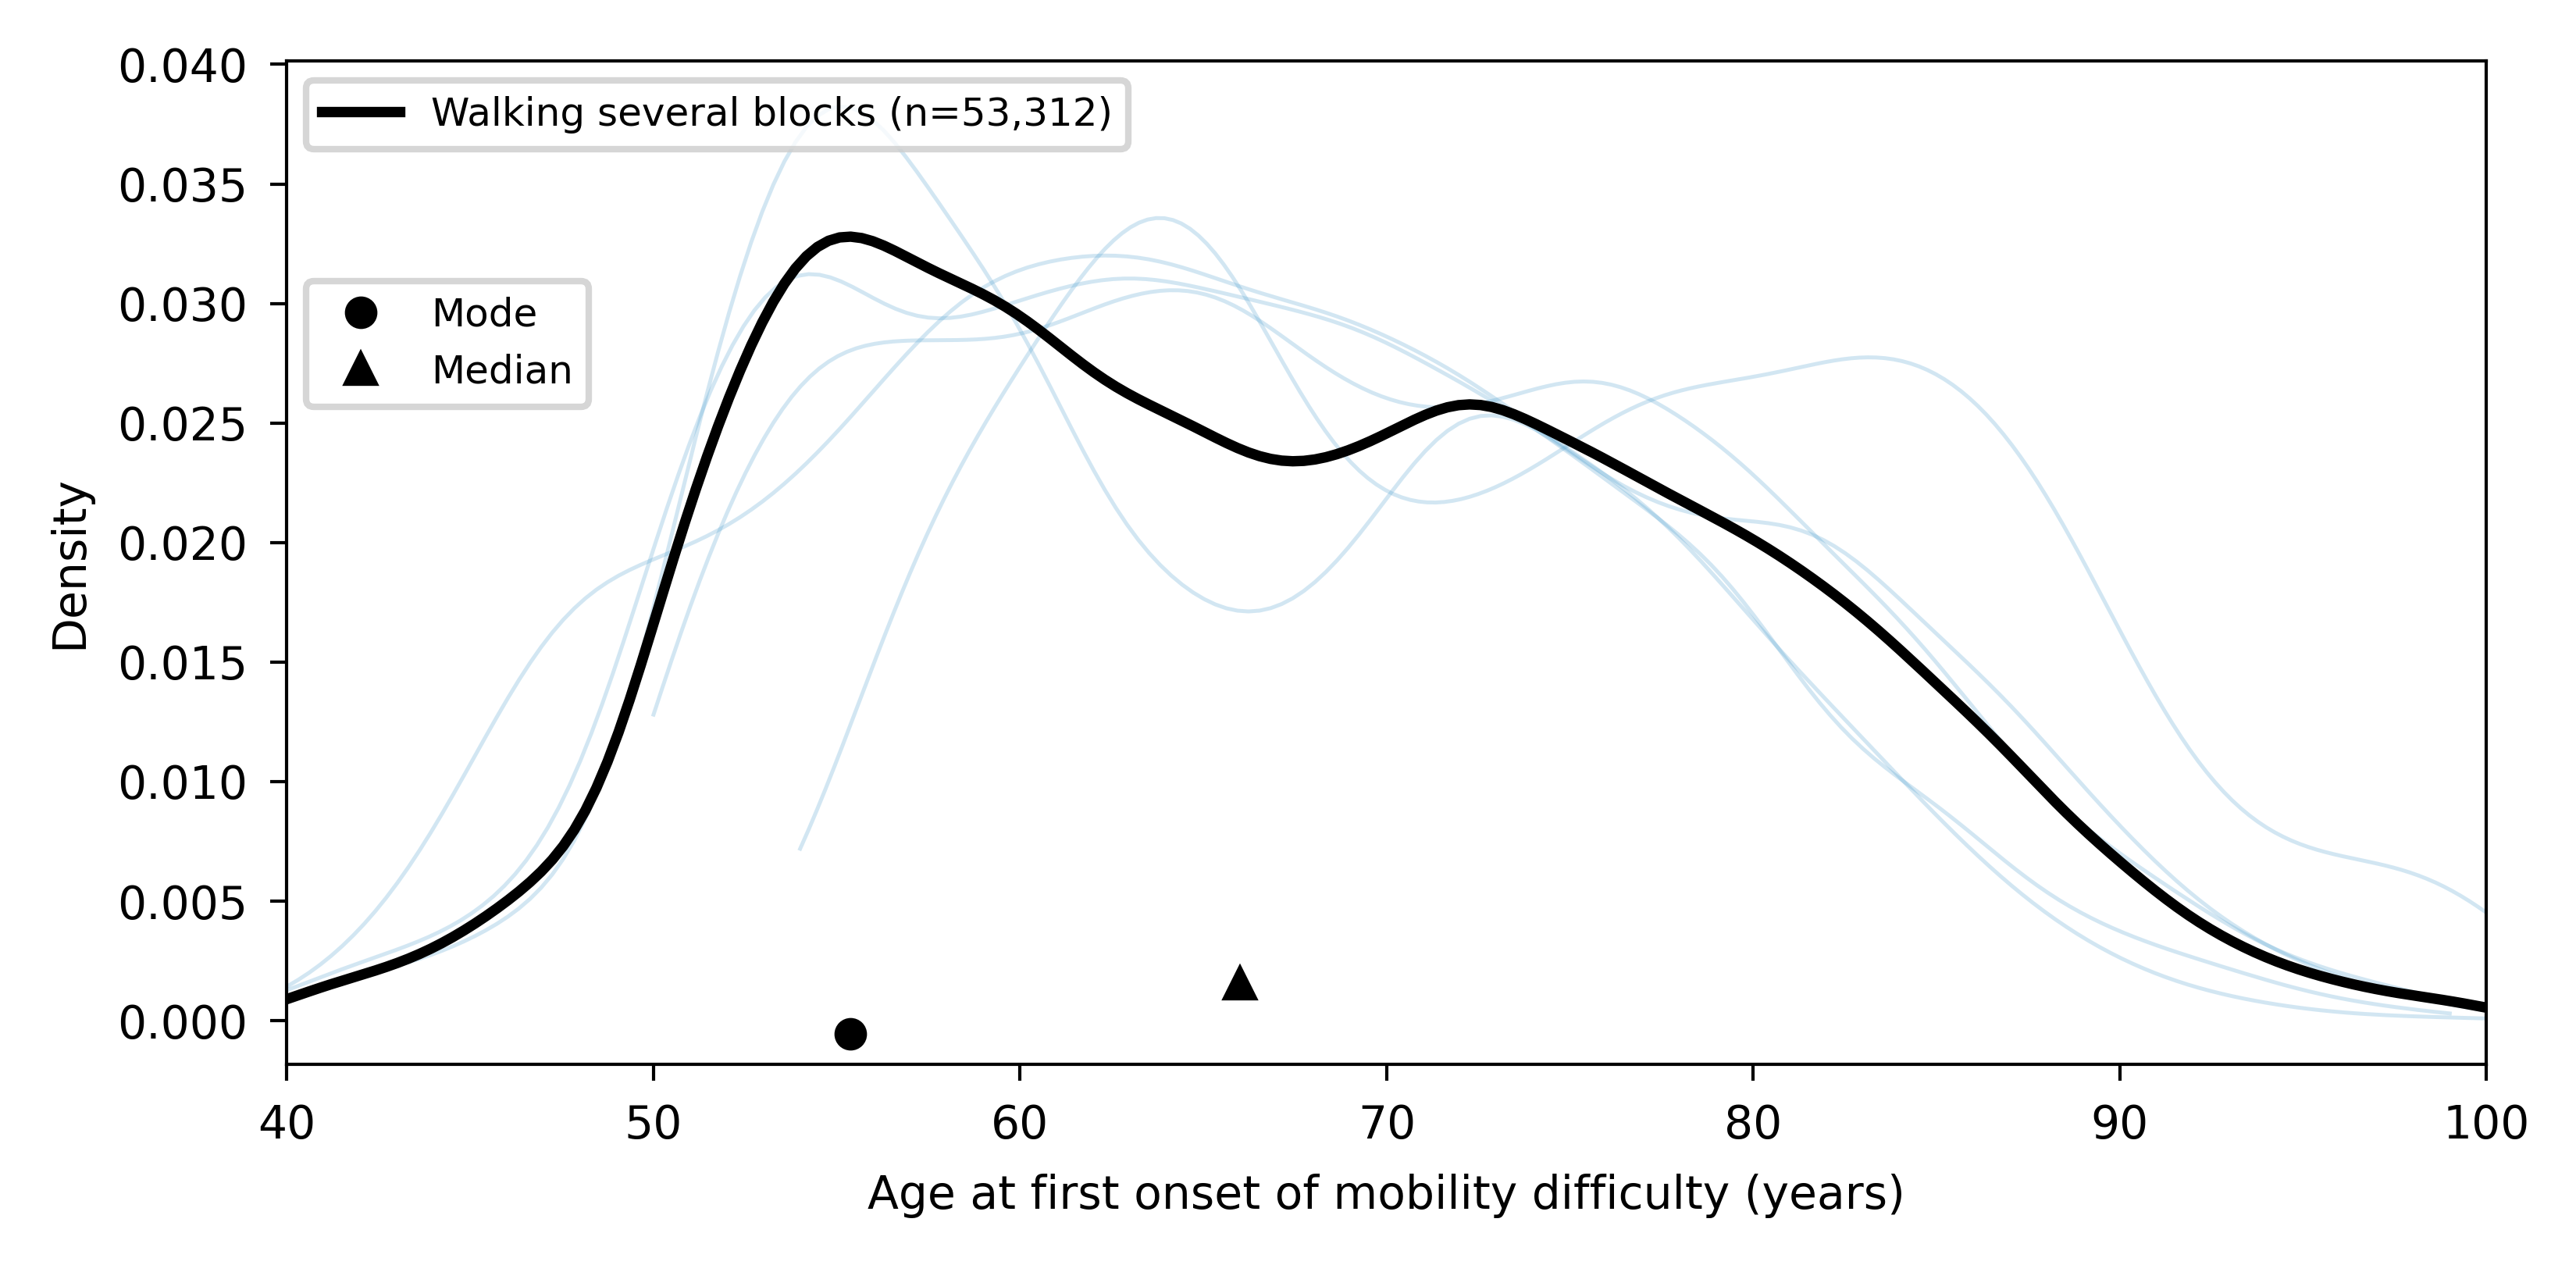

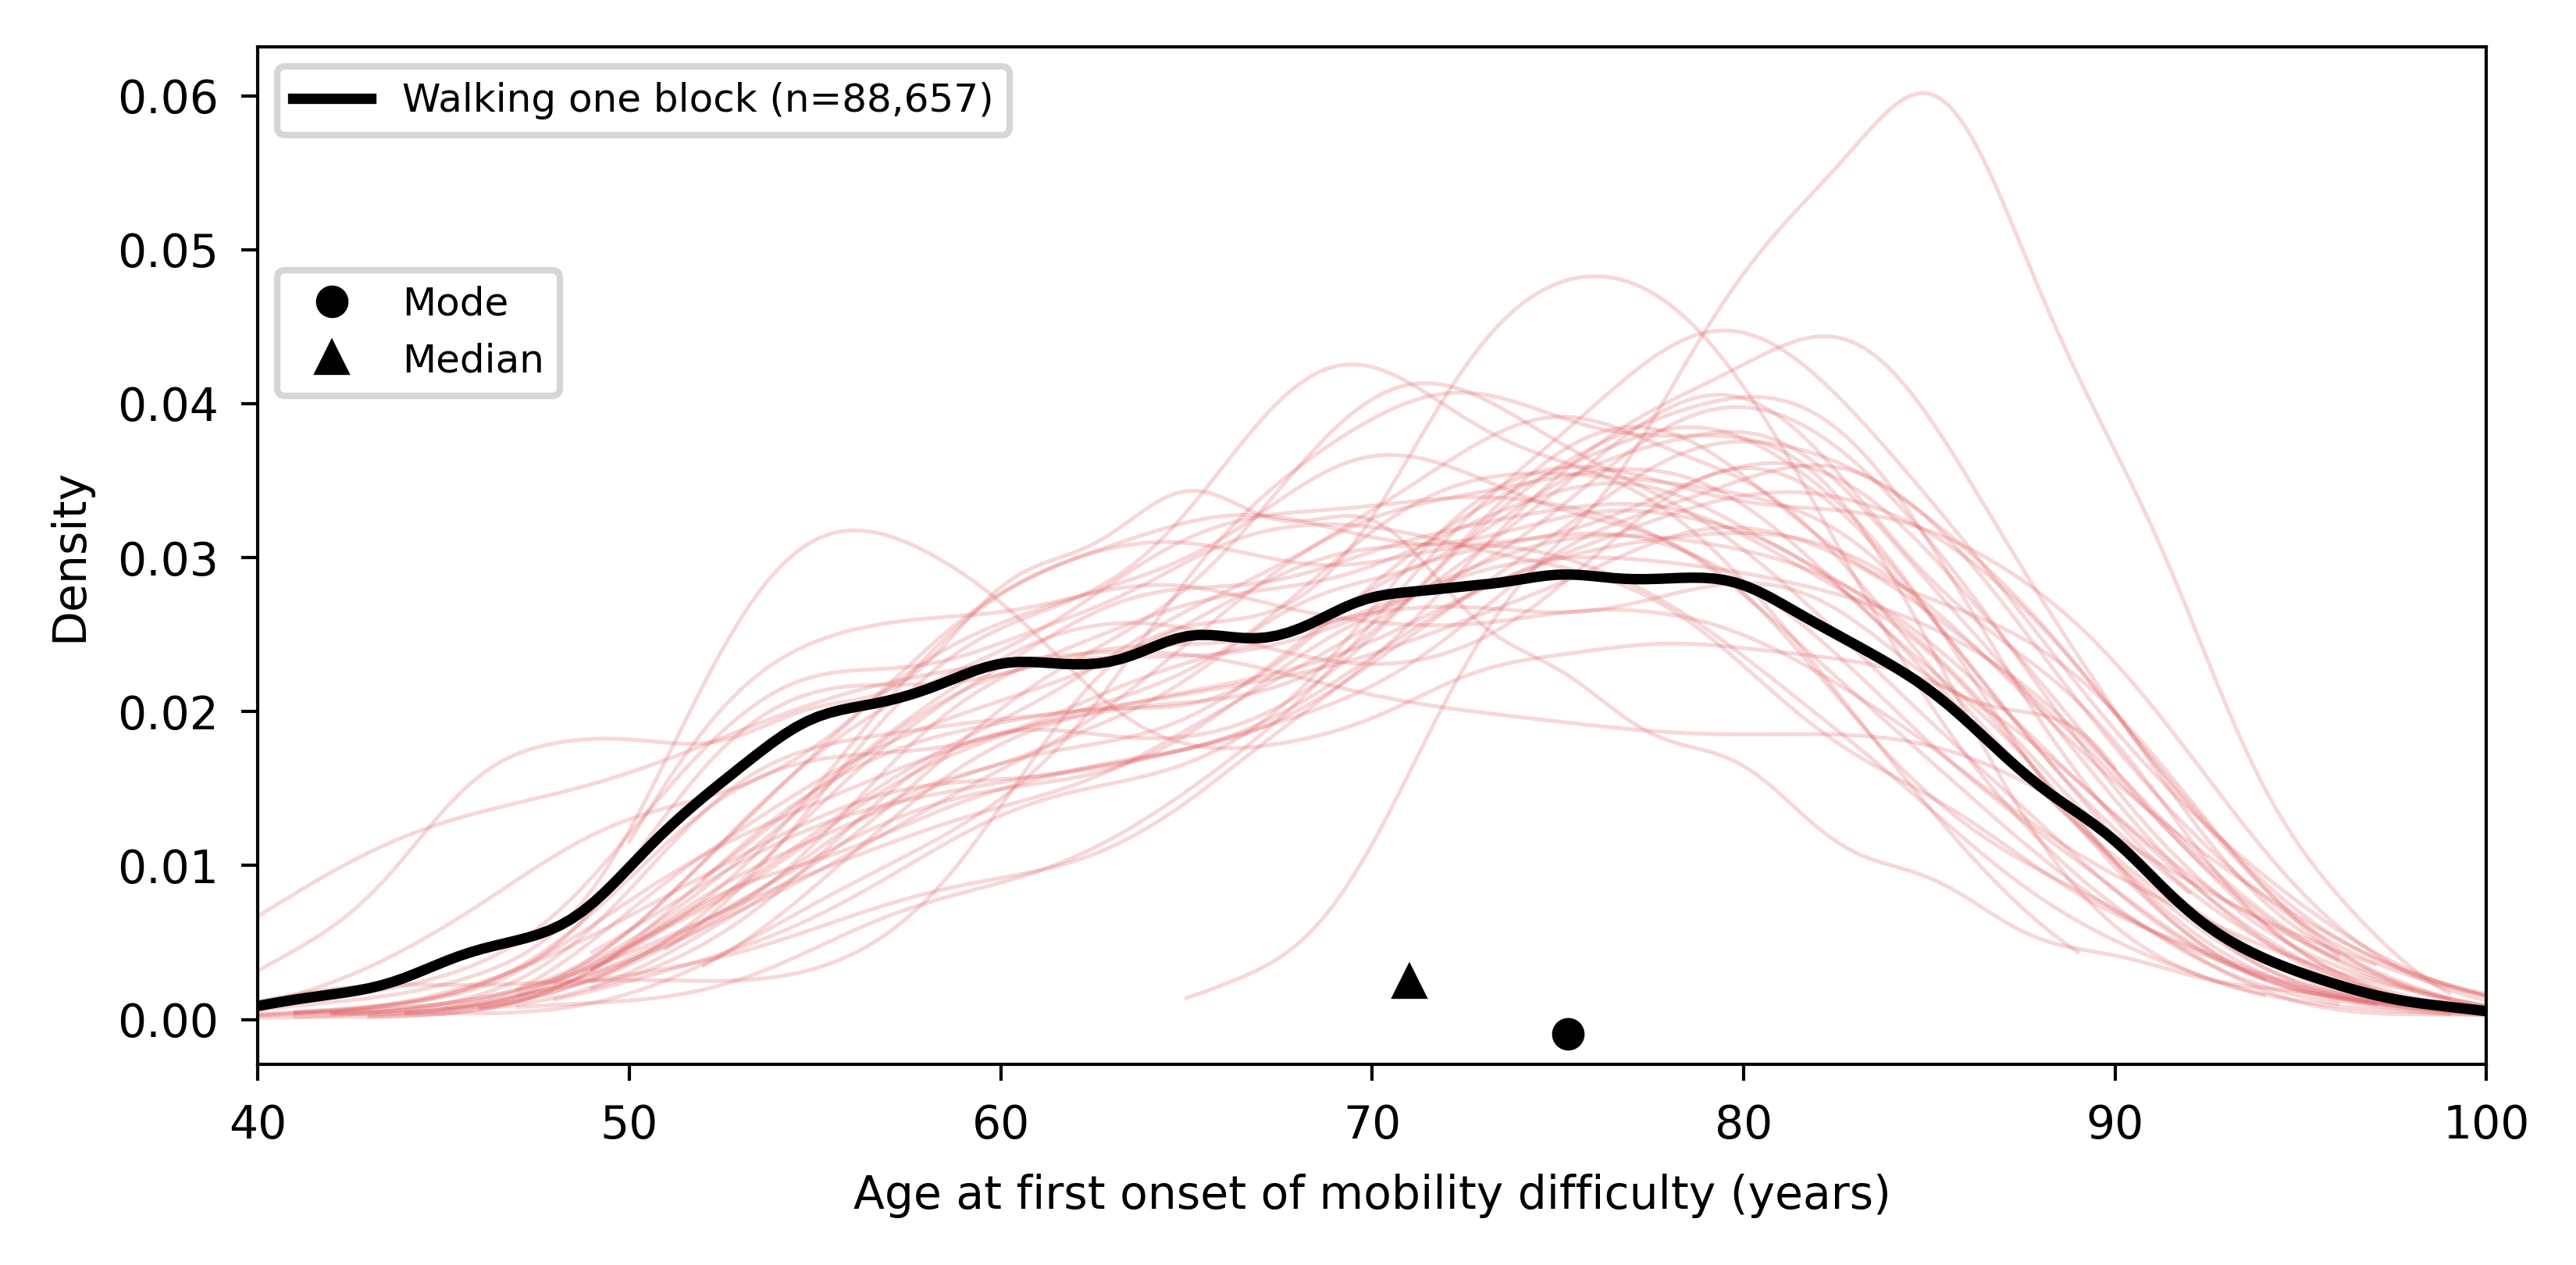

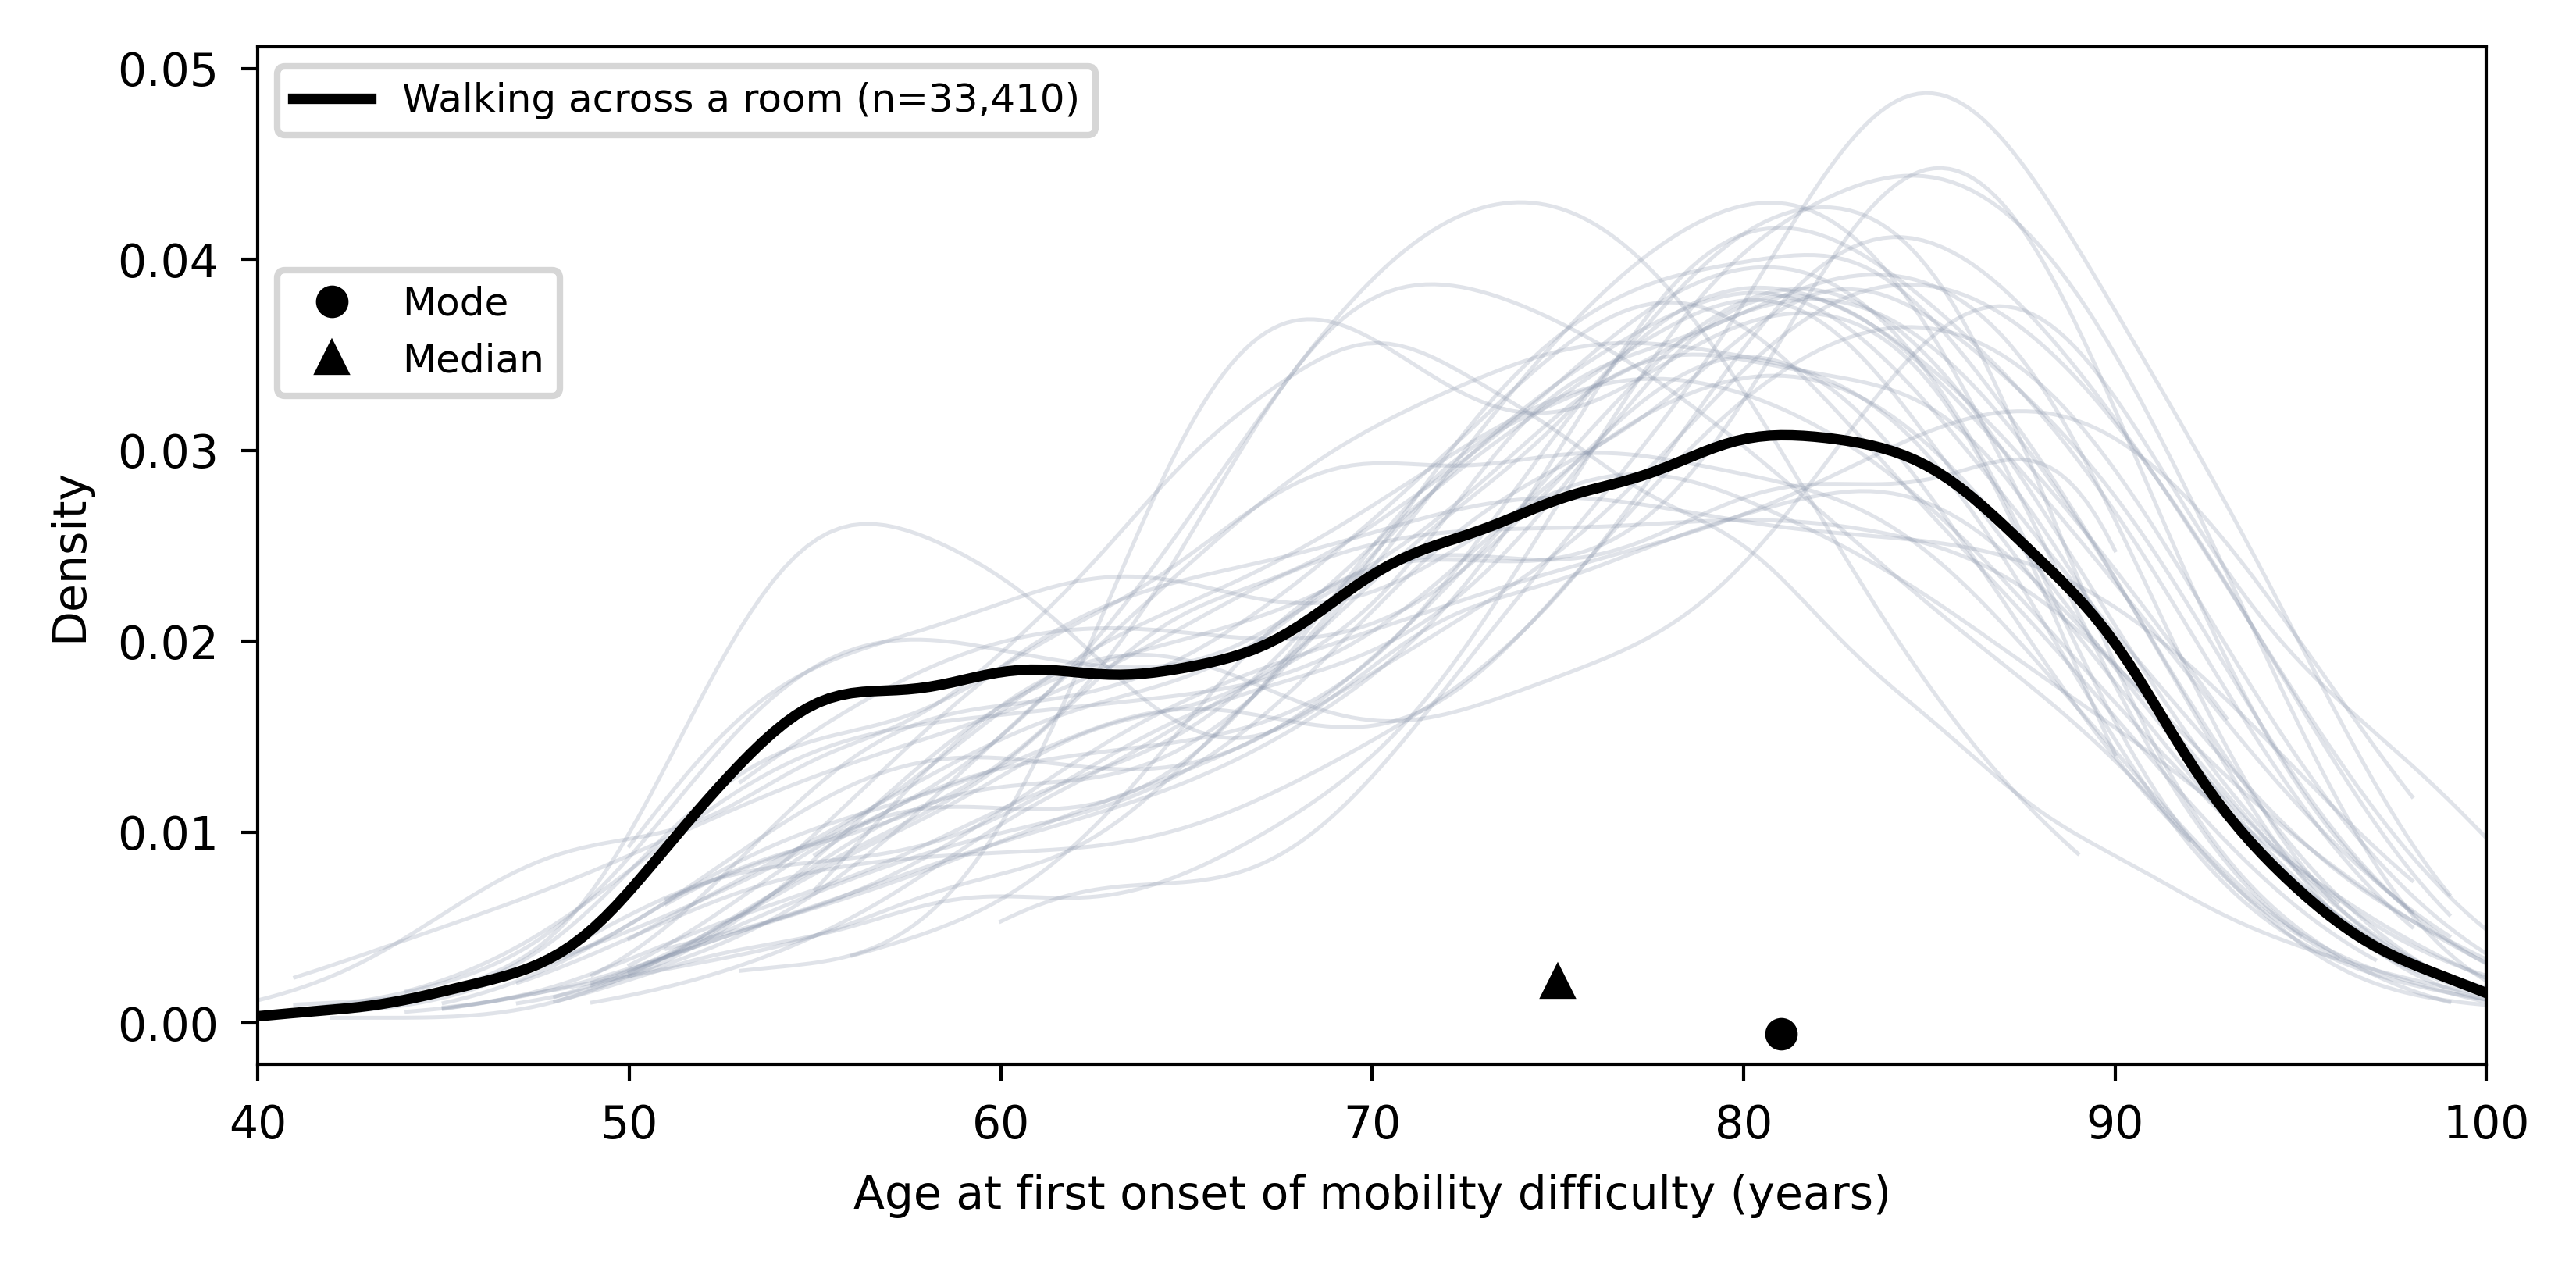

Saved merged plots to: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/merged


In [60]:
# (9) Per-variable merged (all countries + global)
for v in ["rwalksa", "rwalk1a", "rwalkra"]:
    fig, ax = plt.subplots(figsize=(W_INCH_DOUBLE*0.8, H_INCH_SINGLE), dpi=600)
    for ctry, g in aoo_data[v].groupby("country"):
        vals = g["aoo"].values
        xg, yg = kde_curve(vals)
        if xg is None:
            continue
        ax.plot(xg, yg, color=COLORS[v], linewidth=0.6, alpha=0.25)
    global_vals = aoo_data[v]["aoo"].values
    label = f"{LABELS[v]} (n={len(global_vals):,})"
    plot_density(ax, global_vals, "black", label, lw=1.6, alpha_fill=0.0)
    mx = mode_x(global_vals)
    add_mode_marker(ax, mx, "black")
    if len(global_vals) > 0:
        med = float(np.median(global_vals))
        add_median_marker(ax, med, "black")
    ax.set_xlabel("Age at first onset of mobility difficulty (years)", fontsize=FONT_SIZE)
    ax.set_ylabel("Density", fontsize=FONT_SIZE)
    ax.set_xlim(X_MIN, X_MAX)
    add_marker_legend(ax, FONT_SIZE-1)
    theme_std(ax, font_size=FONT_SIZE)
    plt.tight_layout()
    plt.show()
    save_plot(fig, os.path.join(MERGED_DIR, f"aoo_density_merged_{v}.png"))

print("Saved merged plots to:", MERGED_DIR)

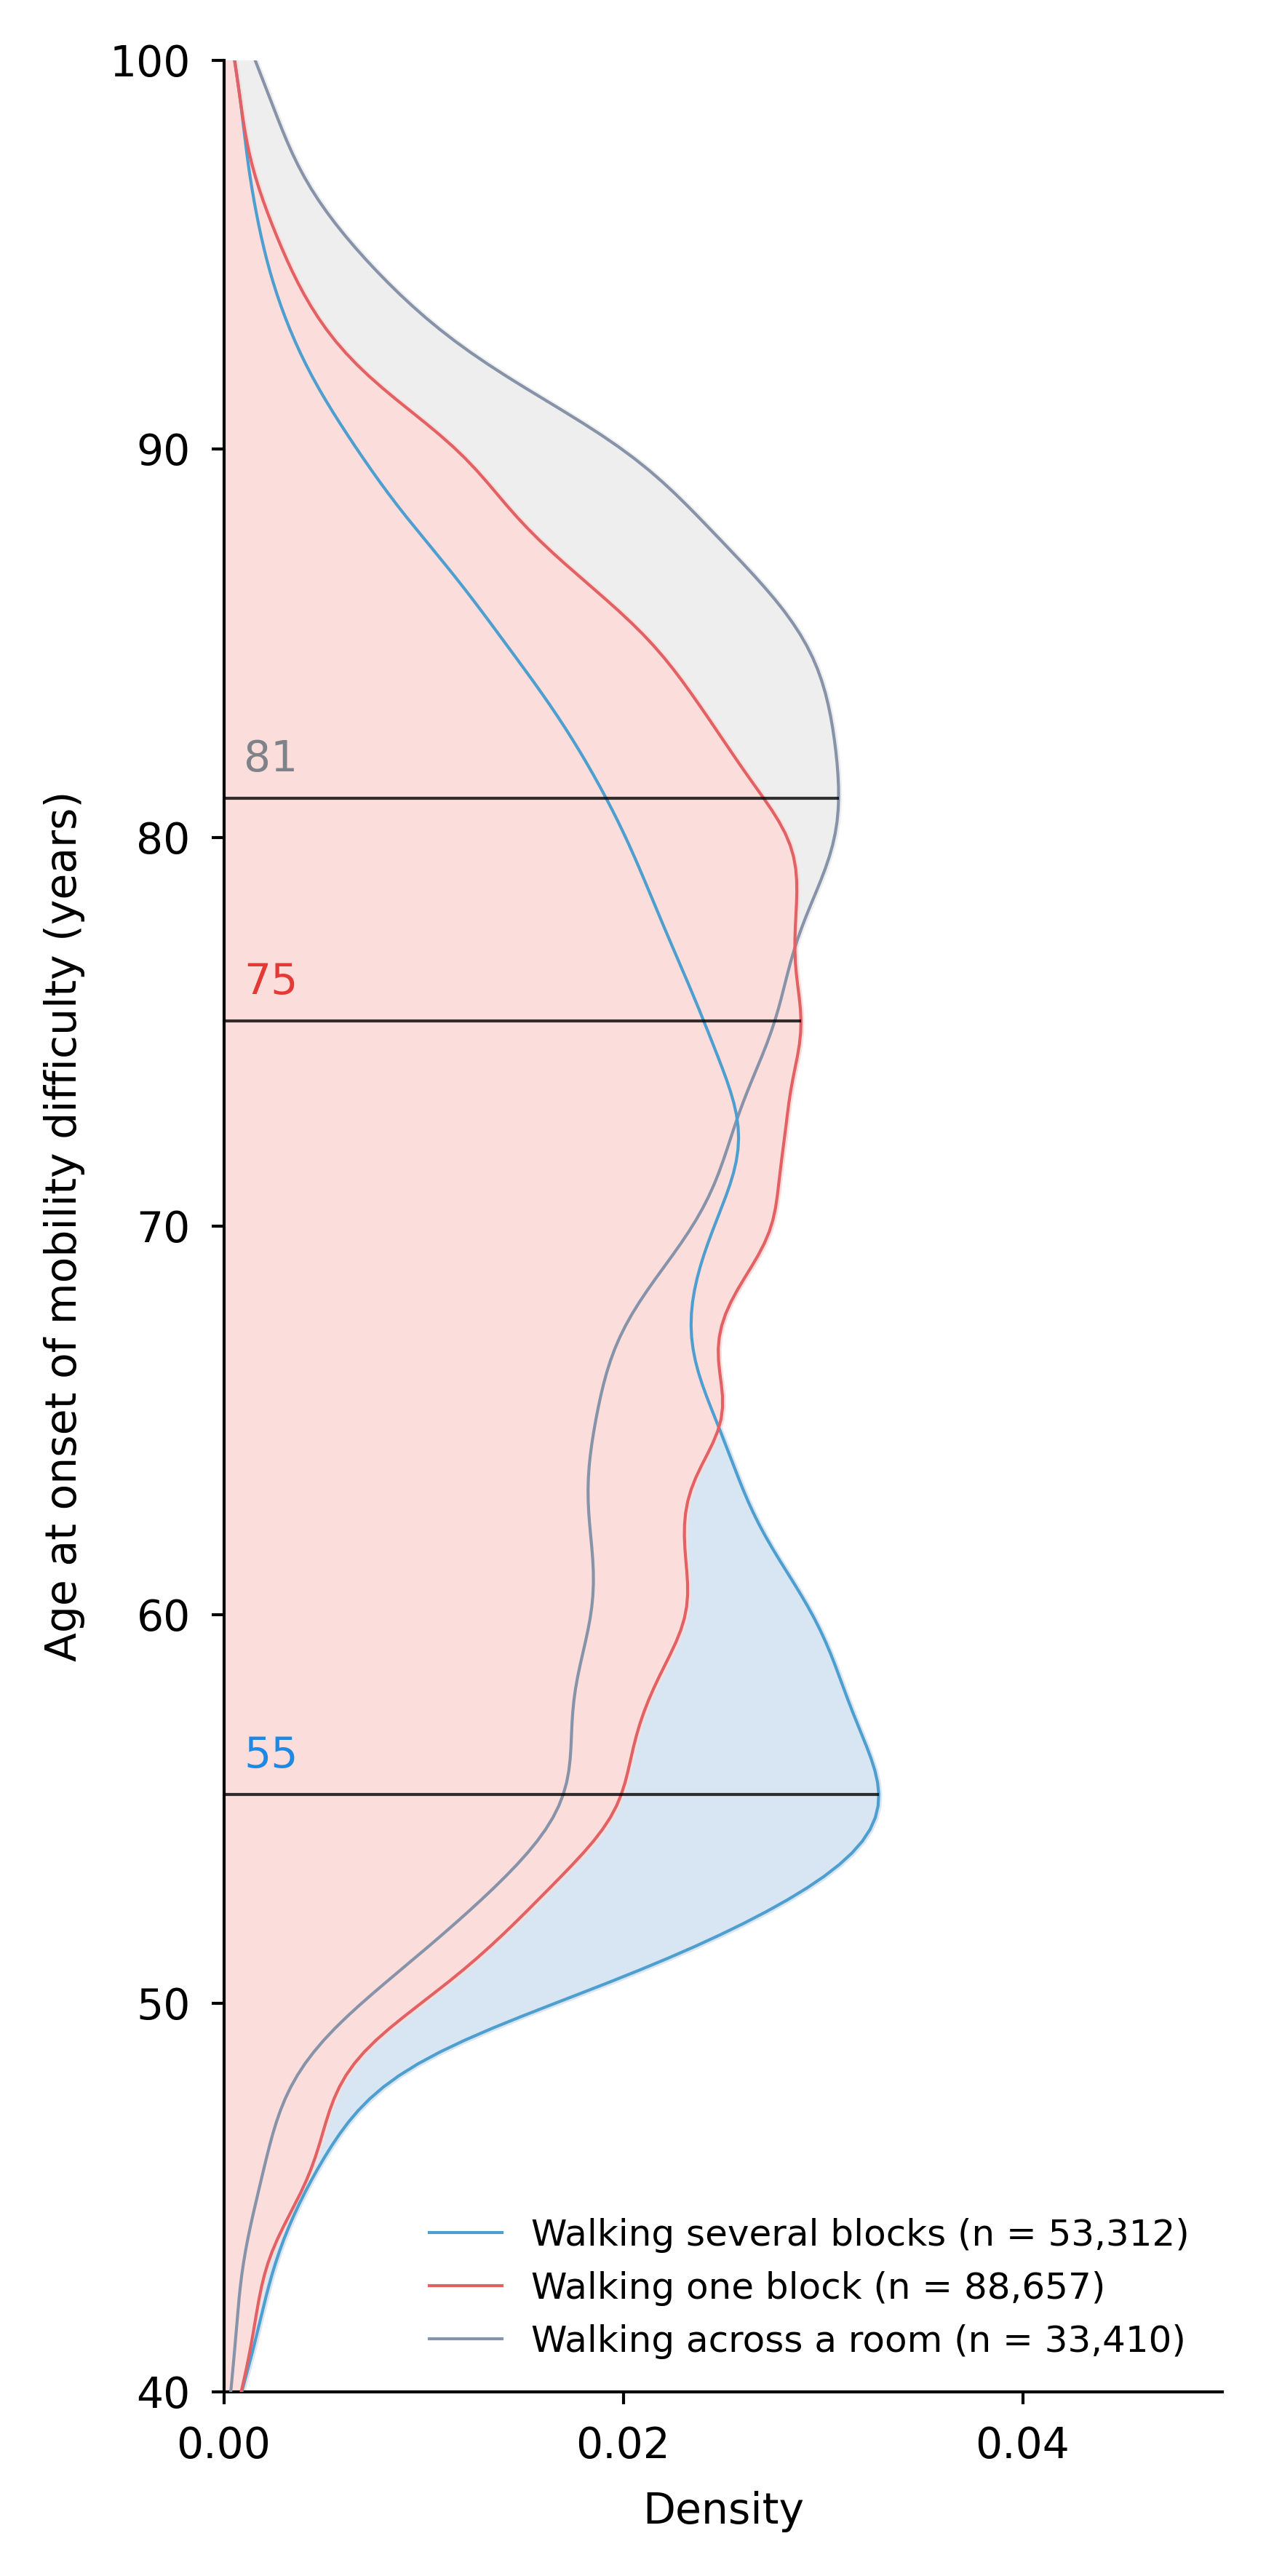

Saved filled global 3-variable plot to: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/global
Countries contributing to mode by variable: {'rwalkra': 37, 'rwalksa': 5, 'rwalk1a': 39}


In [51]:
# (10) Global combined (three variables) with filled density
fig, ax = plt.subplots(figsize=(3,6), dpi=600)

# Fill/plot order: bottom -> top
plot_order = ["rwalkra", "rwalksa", "rwalk1a"]
fill_colors = {
    "rwalkra": "#EEEEEE",  # low-saturation silver
    "rwalk1a": "#FBDEDC",  # low-saturation red
    "rwalksa": "#D8E6F3",  # low-saturation blue
}
mode_text_colors = {
    "rwalkra": "#7F8289",  # higher-saturation silver
    "rwalk1a": "#E53935",  # higher-saturation red
    "rwalksa": "#1E88E5",  # higher-saturation blue
}
mode_country_counts = {}
mode_marks = []
for v in plot_order:
    # global curve (bold + fill)
    vals = aoo_data[v]["aoo"].values
    if len(vals) == 0:
        continue
    label = f"{LABELS[v]} (n = {len(vals):,})"
    xg, yg = kde_curve(vals)
    if xg is None:
        continue
    ax.plot(yg, xg, color=COLORS[v], linewidth=0.5, label=label, zorder=3)
    ax.fill_betweenx(xg, 0, yg, color=fill_colors[v], alpha=1, zorder=2)
    mod = mode_x(vals)
    if mod is not None and np.isfinite(mod):
        dens_at_mod = float(np.interp(mod, xg, yg))
        mode_marks.append({
            "mod": mod,
            "dens": dens_at_mod,
            "color": mode_text_colors[v],
        })
    mode_country_counts[v] = aoo_data[v]["country"].nunique()

# mode lines/text on top
for m in mode_marks:
    ax.hlines(m["mod"], xmin=0.0, xmax=m["dens"], colors="black", linestyles="-", linewidth=0.5, alpha=0.8, zorder=5)
    ax.text(
        0.001,
        m["mod"] + 1.0,
        f"{int(round(m['mod']))}",
        color=m["color"],
        fontsize=FONT_SIZE,
        va="center",
        ha="left",
        zorder=6,
    )

ax.set_xlabel("Density", fontsize=FONT_SIZE)
ax.set_ylabel("Age at onset of mobility difficulty (years)", fontsize=FONT_SIZE)
ax.set_xlim(0.00, 0.05)
ax.set_xticks([0.00, 0.02, 0.04])
ax.set_ylim(40, 100)
ax.set_yticks([40, 50, 60, 70, 80, 90, 100])
handles, labels = ax.get_legend_handles_labels()
legend_order = ["rwalksa", "rwalk1a", "rwalkra"]
ordered_handles = []
ordered_labels = []
for v in legend_order:
    prefix = LABELS[v]
    for h, l in zip(handles, labels):
        if l.startswith(prefix):
            ordered_handles.append(h)
            ordered_labels.append(l)
            break
ax.legend(ordered_handles, ordered_labels, loc="lower right", frameon=False, fontsize=6)
theme_std(ax, font_size=FONT_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)
ax.tick_params(axis="both", width=0.5, length=2)
plt.tight_layout()
plt.show()
save_plot(fig, os.path.join(GLOBAL_DIR, "aoo_density_3vars_global_filled.png"))
print("Saved filled global 3-variable plot to:", GLOBAL_DIR)
print("Countries contributing to mode by variable:", mode_country_counts)

In [52]:
# (11) Mean, median, and mode (global AOO)
rows = []
for v in ["rwalkra", "rwalksa", "rwalk1a"]:
    vals = aoo_data[v]["aoo"].dropna().values
    n = len(vals)
    if n == 0:
        continue

    mean_val = float(np.mean(vals))
    median_val = float(np.median(vals))
    mode_val = mode_x(vals)

    rows.append({
        "variable": v,
        "n": n,
        "mean": mean_val,
        "median": median_val,
        "mode": mode_val,
    })

if rows:
    out = pd.DataFrame(rows)
    out_display = out.copy()
    for col in ["mean", "median", "mode"]:
        out_display[col] = out_display[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "nan")

    print("\n=== Global AOO: mean, median, mode ===")
    print(out_display.to_string(index=False))
else:
    print("No AOO data available for summary stats.")


=== Global AOO: mean, median, mode ===
variable     n  mean median  mode
 rwalkra 33410 73.86  75.00 81.01
 rwalksa 53312 66.90  66.00 55.38
 rwalk1a 88657 70.53  71.00 75.28


In [53]:
# (12) Countries contributing / missing for AOO
all_countries = sorted([c for c in raw['country'].unique() if pd.notna(c) and str(c).strip()!=''])
countries_with_aoo = sorted(set().union(*(set(aoo_data[v]['country'].dropna().unique()) for v in aoo_data)))

print(f"Total countries in raw data: {len(all_countries)}")
print(f"Countries with any AOO rows: {len(countries_with_aoo)}")

# show full lists if small, else show count + first 50
def pretty_list(lst, max_show=50):
    if len(lst) <= max_show:
        return ", ".join(lst)
    return ", ".join(lst[:max_show]) + f", ... (and {len(lst)-max_show} more)"

print("\nCountries with AOO (sample):")
print(pretty_list(countries_with_aoo, max_show=200))

missing = sorted(set(all_countries) - set(countries_with_aoo))
print(f"\nCountries missing AOO (count={len(missing)}):")
print(pretty_list(missing, max_show=200))

# per-variable breakdown
for v in ["rwalksa", "rwalk1a", "rwalkra"]:
    cts = sorted(aoo_data[v]['country'].dropna().unique())
    print(f"\nVariable {v}: countries with AOO = {len(cts)}")
    print(pretty_list(cts, max_show=100))

# save to CSV for downstream use
out_dir = os.path.join(GLOBAL_DIR, "meta")
os.makedirs(out_dir, exist_ok=True)
import csv
with open(os.path.join(out_dir, 'countries_with_aoo.csv'), 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['country'])
    for c in countries_with_aoo:
        writer.writerow([c])
with open(os.path.join(out_dir, 'countries_missing_aoo.csv'), 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['country'])
    for c in missing:
        writer.writerow([c])
print(f"\nSaved country lists to: {out_dir}")

Total countries in raw data: 40
Countries with any AOO rows: 40

Countries with AOO (sample):
Australia, Austria, Belgium, Brazil, Bulgaria, China, Costa Rica, Croatia, Cyprus, Czech Republic, Denmark, England, Estonia, Finland, France, Germany, Greece, Hungary, India, Ireland, Israel, Italy, Japan, Korea, Latvia, Lithuania, Luxembourg, Malta, Mexico, Netherlands, Poland, Portugal, Romania, Slovakia, Slovenia, South Africa, Spain, Sweden, Switzerland, USA

Countries missing AOO (count=0):


Variable rwalksa: countries with AOO = 5
Brazil, China, Costa Rica, Mexico, USA

Variable rwalk1a: countries with AOO = 39
Australia, Austria, Belgium, Brazil, Bulgaria, China, Croatia, Cyprus, Czech Republic, Denmark, England, Estonia, Finland, France, Germany, Greece, Hungary, India, Ireland, Israel, Italy, Japan, Korea, Latvia, Lithuania, Luxembourg, Malta, Mexico, Netherlands, Poland, Portugal, Romania, Slovakia, Slovenia, South Africa, Spain, Sweden, Switzerland, USA

Variable rwalkra: countrie

In [57]:
# (13) Dataset share pie charts for the three AOO variables
import os
import pandas as pd
import matplotlib.pyplot as plt

ISO_PATH = os.path.join(PROJECT_ROOT, "data", "iso40.csv")
ISO_DF = pd.read_csv(ISO_PATH)
ISO_DF["isocountry_c"] = ISO_DF["isocountry_c"].astype(str).str.strip()
ISO_DF["dataset"] = ISO_DF["dataset"].astype(str).str.strip()

DATASET_DIR = os.path.join(GLOBAL_DIR, "dataset_share")
os.makedirs(DATASET_DIR, exist_ok=True)

VAR_ORDER = ["rwalksa", "rwalk1a", "rwalkra"]
VAR_TITLES = {
    "rwalksa": "Walking several blocks",
    "rwalk1a": "Walking one block",
    "rwalkra": "Walking across a room",
}

for v in VAR_ORDER:
    df = aoo_data[v].copy()
    df["country"] = df["country"].astype(str).str.strip()
    merged = df.merge(
        ISO_DF[["isocountry_c", "dataset"]],
        left_on="country",
        right_on="isocountry_c",
        how="left",
    )

    unmatched = sorted(merged.loc[merged["dataset"].isna(), "country"].dropna().unique())
    if unmatched:
        print(f"\n{v}: unmatched countries (not found in iso40.csv):")
        print(", ".join(unmatched))

    sample_counts = (
        merged["dataset"]
        .fillna("Unmatched")
        .value_counts()
        .sort_values(ascending=False)
    )
    sample_total = int(sample_counts.sum())

    fig, ax = plt.subplots(figsize=(7.8, 4.8), dpi=300)
    fig.patch.set_alpha(0.0)
    ax.set_facecolor("none")
    fig.subplots_adjust(left=0.05, right=0.72, top=0.96, bottom=0.06)

    pie_colors = plt.cm.tab20.colors[: len(sample_counts)]

    wedges, _, autotexts = ax.pie(
        sample_counts.values,
        colors=pie_colors,
        startangle=90,
        counterclock=False,
        autopct=lambda p: f"{p:.1f}%" if p >= 5 else "",
        pctdistance=0.68,
        labeldistance=1.12,
        textprops={"fontsize": 10},
        wedgeprops={"linewidth": 0.6, "edgecolor": "white"},
    )

    legend_labels = [f"{name} ({int(count):,})" for name, count in sample_counts.items()]
    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=False,
        fontsize=10,
        borderaxespad=0.0,
    )

    ax.set_aspect("equal")
    out_path = os.path.join(DATASET_DIR, f"aoo_dataset_share_{v}.pdf")
    fig.savefig(out_path, dpi=DPI_OUT, facecolor="none", edgecolor="none", transparent=True)
    plt.close(fig)
    print(f"Saved: {out_path}")

print("\nDataset share PDFs saved to:", DATASET_DIR)

Saved: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/global/dataset_share/aoo_dataset_share_rwalksa.pdf
Saved: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/global/dataset_share/aoo_dataset_share_rwalk1a.pdf
Saved: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/global/dataset_share/aoo_dataset_share_rwalkra.pdf

Dataset share PDFs saved to: /Users/karwailin/Desktop/OAwalk/results/f1_aoo/global/dataset_share
